# Samudra landmask

Since Samudra's output does not provide an easy to use landmask, we create our own to be reused later. Our method consists of picking the values which are ***exactly*** 0 in the SSH output. If that doesn't work perfectly, we can just also use the SST.

In [1]:
from pathlib import Path

import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
rollout_path = Path("../Rollouts/2025-12-04-1Y_Sim-OM4_thermo")

sim_ds = xr.open_dataset(rollout_path / "predictions.zarr")
sim_ds

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


<xarray.Dataset>
Dimensions:    (lat: 180, lon: 360, time: 70)
Coordinates:
    areacello  (lat, lon) float64 ...
  * lat        (lat) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24
  * lon        (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) int64 0 1 2 3 4 5 6 7 8 9 ... 21 22 23 24 25 26 27 28 29
Data variables: (12/39)
    so_0       (time, lat, lon) float32 ...
    so_1       (time, lat, lon) float32 ...
    so_10      (time, lat, lon) float32 ...
    so_11      (time, lat, lon) float32 ...
    so_12      (time, lat, lon) float32 ...
    so_13      (time, lat, lon) float32 ...
    ...         ...
    thetao_5   (time, lat, lon) float32 ...
    thetao_6   (time, lat, lon) float32 ...
    thetao_7   (time, lat, lon) float32 ...
    thetao_8   (time, lat, lon) float32 ...
    thetao_9   (time, lat, lon) float32 ...
    zos        (time, lat, lon) float32 ...
Attributes:
    model_path:  /Odyssey/private/g22cossi/Samudra/Checkpoints/samudra_thermo...

In [7]:
landmask = sim_ds.zos.mean(dim="time") == 0.0
landmask

<xarray.DataArray 'zos' (lat: 180, lon: 360)>
array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
    areacello  (lat, lon) float64 ...
  * lat        (lat) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24
  * lon        (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

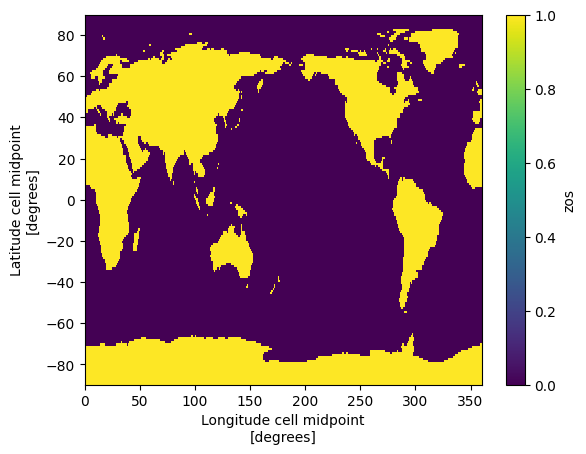

In [4]:
landmask.plot()

Looks pretty good! Let's save it with some proper attributes

In [8]:
landmask.rename("is_land")
landmask.assign_attrs(
    {
        'comments': 'Created from the SSH of a 1Y Samudra simulation',
    }
)

landmask_dir = Path("../Landmasks/")

landmask.to_zarr(landmask_dir / "Landmask.zarr")
landmask.to_netcdf(landmask_dir / "Landmask.nc")



## Some additional tests

Let's check if we get the same result using SST instead

In [6]:
landmask_sst = sim_ds.thetao_0.mean(dim="time") == 0.0

landmask.equals(landmask_sst)

True